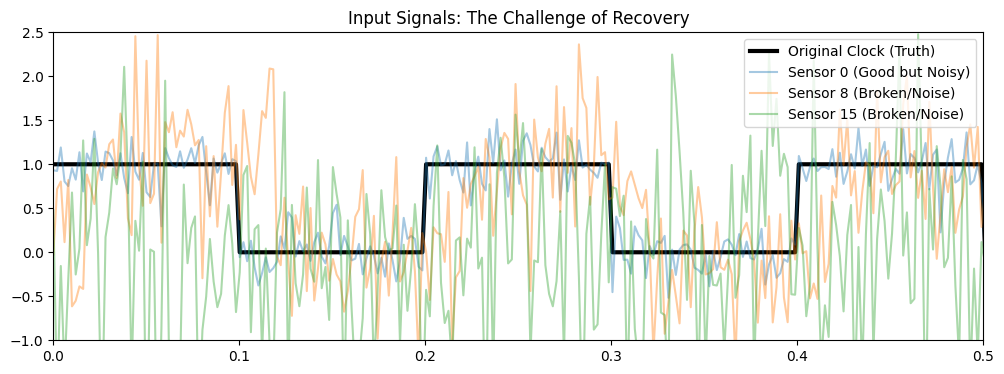

In [1]:
# --- SIGNAL GENERATION (THE DIGITAL CLOCK) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import signal

# np.random.seed(42)
t = np.linspace(0, 1, 500)
# Create a 5Hz square wave (Digital Clock)
true_clock = float(0.5) * (signal.square(2 * np.pi * 5 * t) + 1)

# Generate 20 sensors:
# - 5 sensors are "Good" (Low noise)
# - 5 sensors are "Laggy" (Noisy or distorted)
# - 10 sensors are "Broken" (Pure Gaussian noise)
n_sensors = 20
X = np.zeros((len(t), n_sensors))

for i in range(n_sensors):
    if i < 5: # Good sensors
        X[:, i] = true_clock + np.random.normal(0, 0.2, len(t))
    elif i < 10: # Distorted sensors
        X[:, i] = np.roll(true_clock, 10) + np.random.normal(0, 0.5, len(t))
    else: # Broken sensors
        X[:, i] = np.random.normal(0, 1.0, len(t))

plt.figure(figsize=(12, 4))
plt.plot(t, true_clock, 'k', lw=3, label='Original Clock (Truth)')
plt.plot(t, X[:, 0], alpha=0.4, label='Sensor 0 (Good but Noisy)')
plt.plot(t, X[:, 8], alpha=0.4, label='Sensor 8 (Broken/Noise)')
plt.plot(t, X[:, 15], alpha=0.4, label='Sensor 15 (Broken/Noise)')
plt.title("Input Signals: The Challenge of Recovery")
plt.legend()
plt.ylim(-1.0, 2.5)
plt.xlim(0, 0.5)
plt.show()

In [2]:
# --- DATA PREPARATION ---
# We standardize the sensors. Note: Standardizing a square wave
# pushes values towards -1 and +1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Target for supervised models (Ridge/Lasso)
y = true_clock

In [3]:
# --- RUNNING THE MODELS ---
# 1. Unsupervised: PCA (Only uses X, doesn't know about the 'true_clock' target)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)
# Reconstruct by projecting the first component back
pca_recovery = scaler.inverse_transform(pca.inverse_transform(X_pca))[:, 0]

# 2. Supervised: Ridge (L2)
# alpha = lambda nelle slide
ridge = Ridge(alpha=10).fit(X_scaled, y)
ridge_recovery = ridge.predict(X_scaled)

# 3. Supervised: Lasso (L1) - Should ignore "Broken" sensors completely
lasso = Lasso(alpha=0.05).fit(X_scaled, y)
lasso_recovery = lasso.predict(X_scaled)

Running K-fold cross-validation for Lasso alpha selection...

Best alpha found: 0.0055 with mean MSE: 0.0068


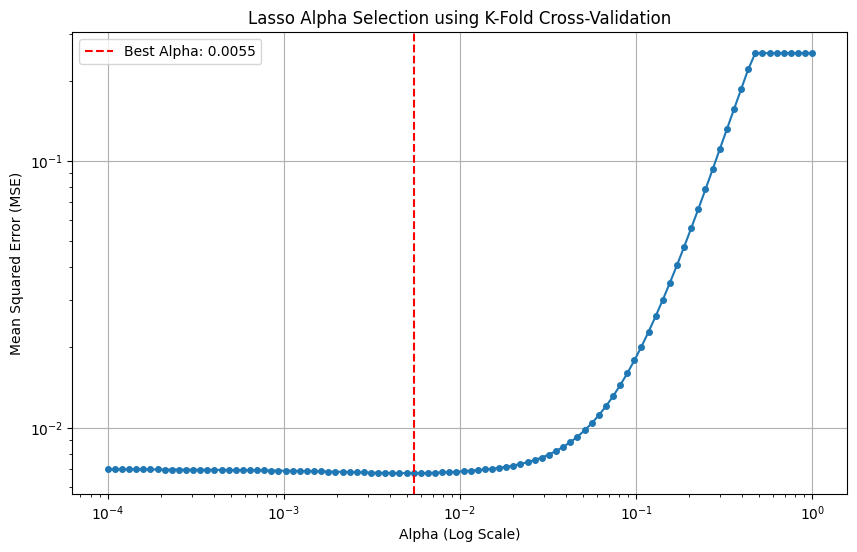


Lasso coefficients with best alpha:
Sensor 0: 0.0985
Sensor 1: 0.1179
Sensor 2: 0.1035
Sensor 3: 0.0950
Sensor 4: 0.0993
Sensor 7: 0.0066


In [4]:
# --- CHOOSE ALPHA WITH CROSS VALIDATION ---

from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

# Define a range of alpha values to test
alphas = np.logspace(-4, 0, 100) # From 0.0001 to 1

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results
mean_mse_scores = []

print("Running K-fold cross-validation for Lasso alpha selection...")

for alpha in alphas:
    mse_scores = []
    #loop over the folds
    for train_index, test_index in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y[train_index], y[test_index]

        lasso_cv = Lasso(alpha=alpha, max_iter=2000) # Increased max_iter for convergence
        lasso_cv.fit(X_train, y_train)
        y_pred = lasso_cv.predict(X_test)
        mse_scores.append(mean_squared_error(y_test, y_pred))
    mean_mse_scores.append(np.mean(mse_scores))

# Find the best alpha
best_alpha_index = np.argmin(mean_mse_scores)
best_alpha = alphas[best_alpha_index]

print(f"\nBest alpha found: {best_alpha:.4f} with mean MSE: {mean_mse_scores[best_alpha_index]:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(alphas, mean_mse_scores, marker='o', linestyle='-', markersize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Alpha Selection using K-Fold Cross-Validation')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best Alpha: {best_alpha:.4f}')
plt.legend()
plt.grid(True)
plt.show()

# Train Lasso with the best alpha
best_lasso = Lasso(alpha=best_alpha, max_iter=2000)
best_lasso.fit(X_scaled, y)

print("\nLasso coefficients with best alpha:")
for i, coef in enumerate(best_lasso.coef_):
    if abs(coef) > 1e-5: # Only print non-negligible coefficients
        print(f"Sensor {i}: {coef:.4f}")

lasso_recovery = lasso.predict(X_scaled)


PCA Component 0 explains 29.19% of variance

Sensor Contributions to PC1 (sorted):
    Sensor   Loading  Abs_Loading       Type
1        1  0.368177     0.368177       Good
4        4  0.367498     0.367498       Good
2        2  0.365206     0.365206       Good
3        3  0.364818     0.364818       Good
0        0  0.360832     0.360832       Good
8        8  0.264128     0.264128  Distorted
7        7  0.257550     0.257550  Distorted
9        9  0.257006     0.257006  Distorted
6        6  0.253872     0.253872  Distorted
5        5  0.253864     0.253864  Distorted
15      15 -0.021344     0.021344     Broken
14      14  0.018929     0.018929     Broken
13      13 -0.017248     0.017248     Broken
17      17  0.015014     0.015014     Broken
16      16  0.013347     0.013347     Broken
11      11 -0.011717     0.011717     Broken
12      12 -0.003558     0.003558     Broken
19      19  0.003425     0.003425     Broken
18      18  0.001064     0.001064     Broken
10      10  0.000

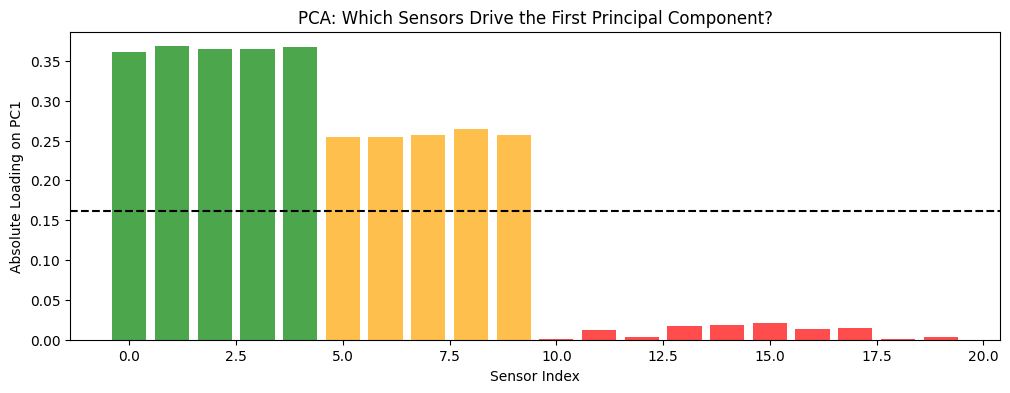


Average loading (Good sensors): 0.3653
Average loading (Distorted sensors): 0.2573
Average loading (Broken sensors): 0.0106


In [5]:
import pandas as pd

# --- PCA VARIANCE ANALYSIS ---

# Get explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_
print(f"PCA Component 0 explains {explained_variance_ratio[0]:.2%} of variance")

# Get the loadings (contributions of each sensor to PC1)
loadings = pca.components_[0]

# Create a dataframe to analyze sensor contributions
sensor_analysis = pd.DataFrame({
    'Sensor': range(n_sensors),
    'Loading': loadings,
    'Abs_Loading': np.abs(loadings),
    'Type': ['Good' if i < 5 else 'Distorted' if i < 10 else 'Broken' for i in range(n_sensors)]
})

# Sort by absolute loading to see which sensors contribute most
sensor_analysis_sorted = sensor_analysis.sort_values('Abs_Loading', ascending=False)
print("\nSensor Contributions to PC1 (sorted):")
print(sensor_analysis_sorted)

# Visualize loadings by sensor type
plt.figure(figsize=(12, 4))
colors = ['green' if t == 'Good' else 'orange' if t == 'Distorted' else 'red' for t in sensor_analysis['Type']]
plt.bar(sensor_analysis['Sensor'], np.abs(sensor_analysis['Loading']), color=colors, alpha=0.7)
plt.axhline(y=np.mean(np.abs(loadings)), color='black', linestyle='--', label='Mean Loading')
plt.xlabel('Sensor Index')
plt.ylabel('Absolute Loading on PC1')
plt.title('PCA: Which Sensors Drive the First Principal Component?')
#plt.legend(['Good Sensors', 'Distorted Sensors', 'Broken Sensors (ignored)'])
plt.show()

print(f"\nAverage loading (Good sensors): {sensor_analysis[sensor_analysis['Type']=='Good']['Abs_Loading'].mean():.4f}")
print(f"Average loading (Distorted sensors): {sensor_analysis[sensor_analysis['Type']=='Distorted']['Abs_Loading'].mean():.4f}")
print(f"Average loading (Broken sensors): {sensor_analysis[sensor_analysis['Type']=='Broken']['Abs_Loading'].mean():.4f}")

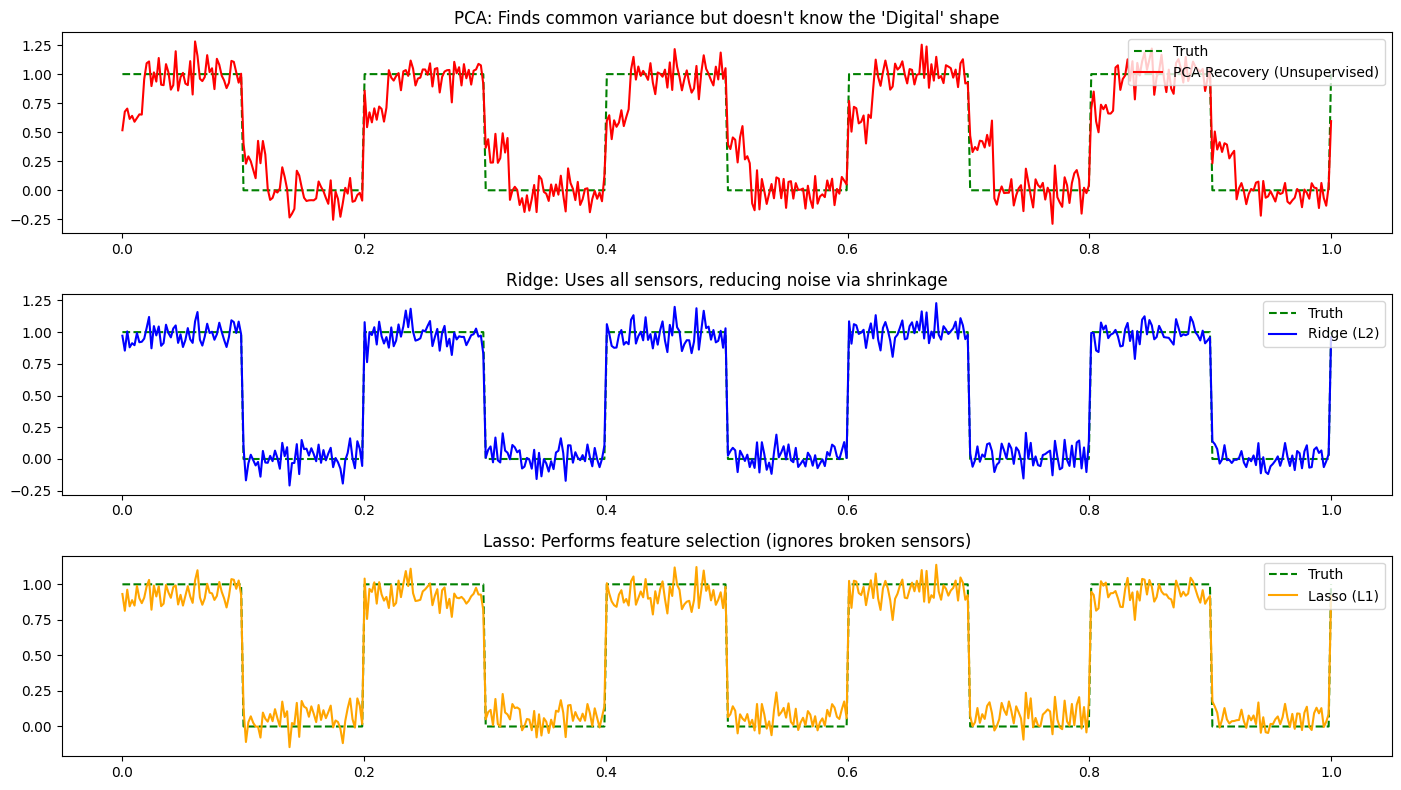

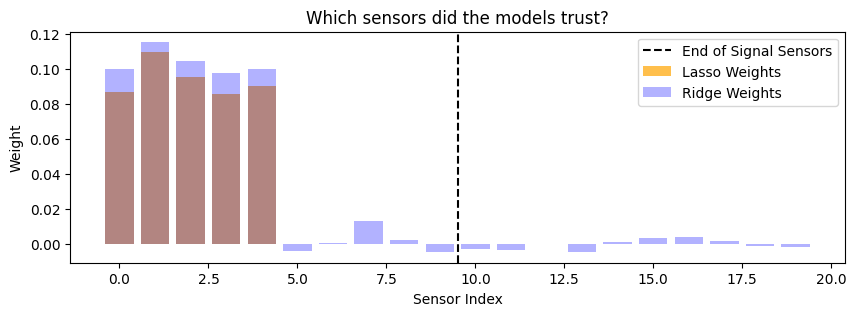

In [6]:
# --- COMPARISON ---
plt.figure(figsize=(14, 8))

# Plot PCA Results
plt.subplot(3, 1, 1)
plt.plot(t, true_clock, 'g--', label='Truth')
plt.plot(t, pca_recovery, 'r', label='PCA Recovery (Unsupervised)')
plt.title("PCA: Finds common variance but doesn't know the 'Digital' shape")
plt.legend(loc='upper right')

# Plot Ridge Results
plt.subplot(3, 1, 2)
plt.plot(t, true_clock, 'g--', label='Truth')
plt.plot(t, ridge_recovery, 'blue', label='Ridge (L2)')
plt.title("Ridge: Uses all sensors, reducing noise via shrinkage")
plt.legend(loc='upper right')

# Plot Lasso Results
plt.subplot(3, 1, 3)
plt.plot(t, true_clock, 'g--', label='Truth')
plt.plot(t, lasso_recovery, 'orange', label='Lasso (L1)')
plt.title("Lasso: Performs feature selection (ignores broken sensors)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- CELL 5: COEFFICIENT INSPECTION ---
plt.figure(figsize=(10, 3))
plt.bar(range(n_sensors), lasso.coef_, color='orange', alpha=0.7, label='Lasso Weights')
plt.bar(range(n_sensors), ridge.coef_, color='blue', alpha=0.3, label='Ridge Weights')
plt.axvline(9.5, color='black', linestyle='--', label='End of Signal Sensors')
plt.title("Which sensors did the models trust?")
plt.xlabel("Sensor Index")
plt.ylabel("Weight")
plt.legend()
plt.show()